In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

In [3]:
# --- Load audio ---
# librosa loads as float32, normalized to [-1.0, 1.0]
# sr=None preserves the original sample rate
audio_path = "sample1.mp3"
y, sr = librosa.load(audio_path, sr=None, mono=True)

Note: Illegal Audio-MPEG-Header 0x3934372c at offset 1604160.
Note: Trying to resync...
Note: Skipped 1024 bytes in input.
[src/libmpg123/parse.c:wetwork():1349] error: Giving up resync after 1024 bytes - your stream is not nice... (maybe increasing resync limit could help).
/var/folders/jp/_n1yy6w143x6rxr2gt1kr6d00000gn/T/ipykernel_1600/2422875126.py:5: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(audio_path, sr=None, mono=True)
/Users/bibekjoshi01/Drive X/Major-Project/venv/lib/python3.12/site-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


## Time Domain Analysis

Sample rate   : 48000 Hz
Total samples : 1924992
Duration      : 40.10 seconds
Amplitude min : -0.7973
Amplitude max : 0.7975


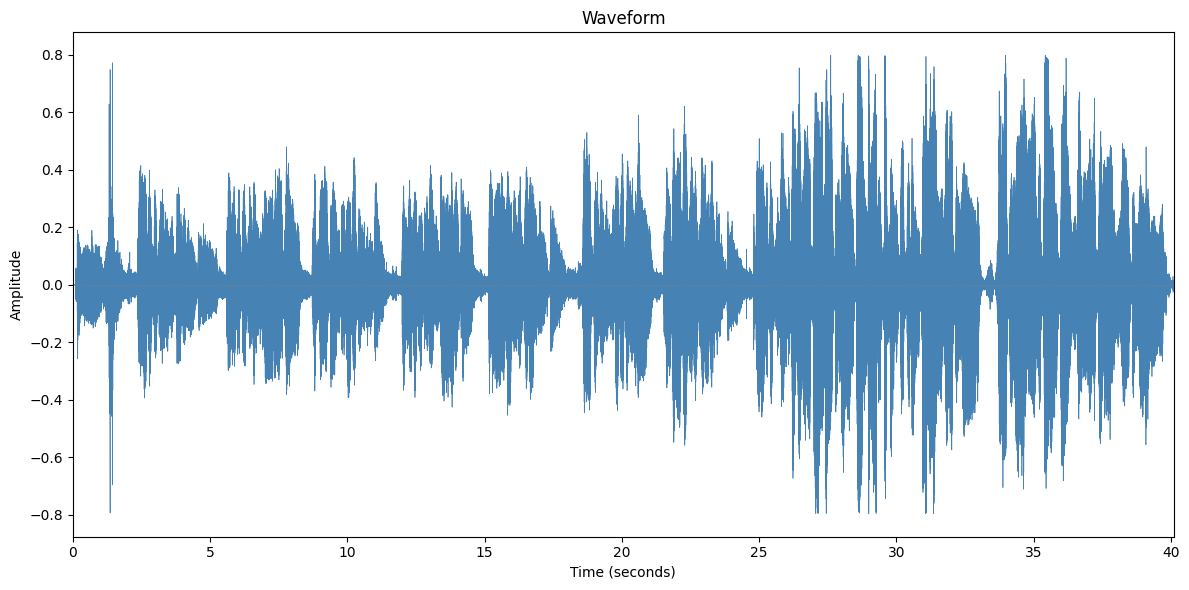

In [5]:
# --- Inspect basics ---
duration = len(y) / sr
print(f"Sample rate   : {sr} Hz")
print(f"Total samples : {len(y)}")
print(f"Duration      : {duration:.2f} seconds")
print(f"Amplitude min : {y.min():.4f}")
print(f"Amplitude max : {y.max():.4f}")

# --- Time axis ---
time = np.linspace(0, duration, num=len(y))

# --- Plot waveform ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time, y, linewidth=0.5, color='steelblue')
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
ax.set_title("Waveform")
ax.set_xlim(0, duration)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')  # zero line
plt.tight_layout()
plt.show()

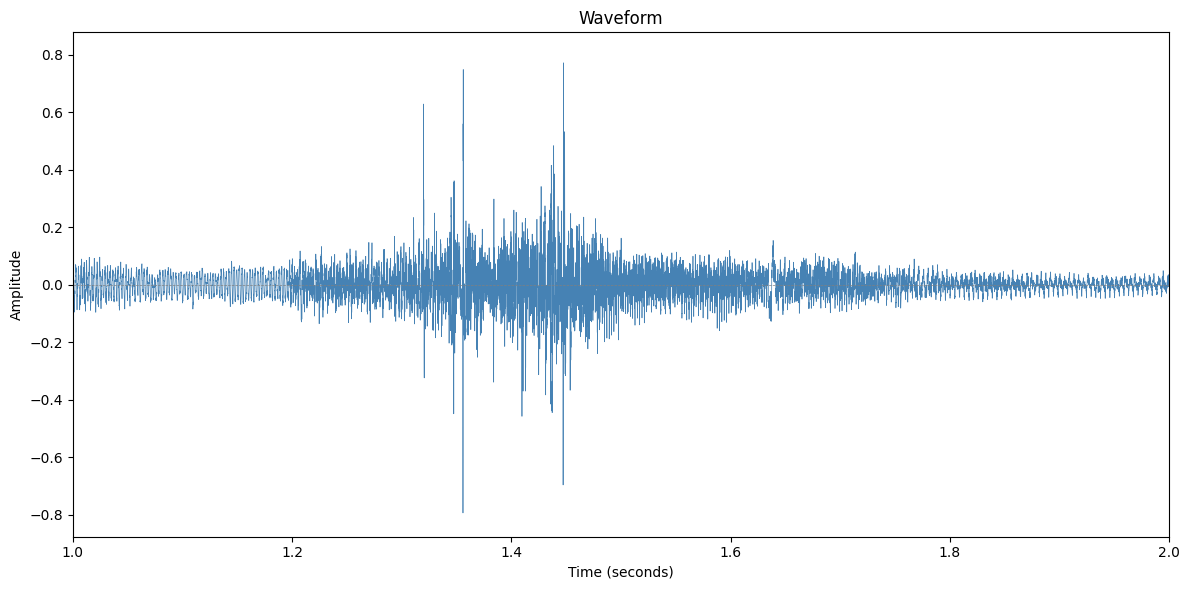

In [11]:
# --- Plot waveform ---
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(time, y, linewidth=0.5, color='steelblue')
ax.set_xlabel("Time (seconds)")
ax.set_ylabel("Amplitude")
ax.set_title("Waveform")
ax.set_xlim(1, 2)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')  # zero line
plt.tight_layout()
plt.show()

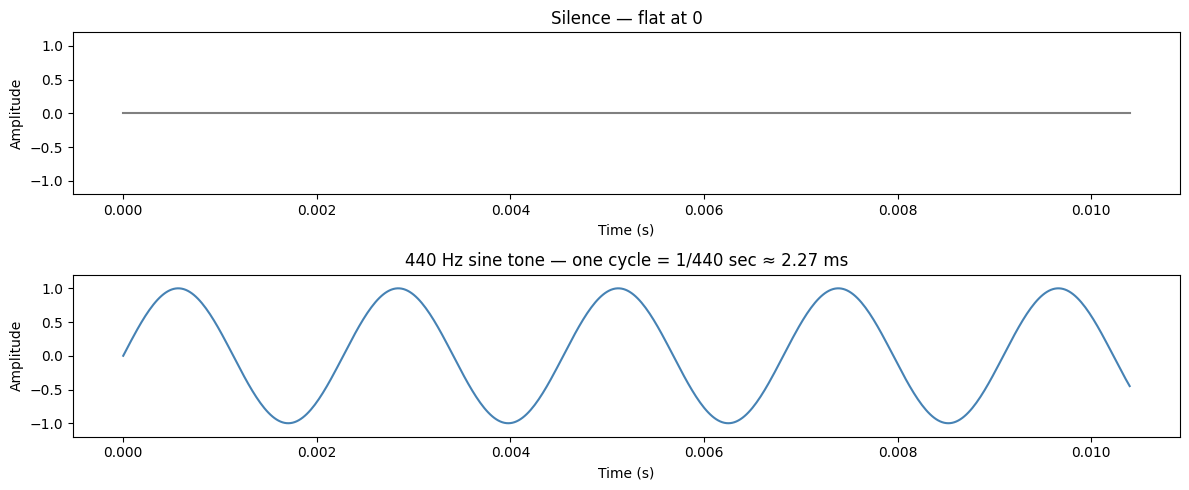

In [12]:
# --- Quick experiment: what does silence look like? ---
# Generate 1 second of silence and 1 second of a 440 Hz tone
silence = np.zeros(sr)
t = np.linspace(0, 1, sr, endpoint=False)
tone_440hz = np.sin(2 * np.pi * 440 * t)  # pure sine wave at 440 Hz (A4)

fig, axes = plt.subplots(2, 1, figsize=(12, 5))
axes[0].plot(t[:500], silence[:500], color='gray')
axes[0].set_title("Silence — flat at 0")
axes[0].set_ylim(-1.2, 1.2)

axes[1].plot(t[:500], tone_440hz[:500], color='steelblue')
axes[1].set_title("440 Hz sine tone — one cycle = 1/440 sec ≈ 2.27 ms")
axes[1].set_ylim(-1.2, 1.2)

for ax in axes:
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Amplitude")

plt.tight_layout()
plt.show()


## Notes
Imagine a microphone as a very fast ruler measuring air pressure 48,000 times every second.

When sound hits it, air pressure goes up and down — the microphone records each measurement as a number:


1. +0.7975 → air is being pushed hard toward the mic (compression, loud moment)
2. 0.0000 → air pressure is at rest (silence)
3. -0.7973 → air is being pulled away from the mic (rarefaction)

## Frequency Domain Analysis

In [14]:
import numpy as np

# Run FFT
fft_result = np.fft.fft(y)           # complex numbers
magnitude   = np.abs(fft_result)      # how strong each frequency is
phase       = np.angle(fft_result)    # we usually ignore this

# Map bin index → Hz
freqs = np.fft.fftfreq(len(y), d=1/sr)

# Only use first half (second half is mirror image)
half = len(y) // 2
magnitude = magnitude[:half]
freqs     = freqs[:half]

# Find the dominant frequency
peak_bin = np.argmax(magnitude)
print(f"Dominant frequency: {freqs[peak_bin]:.1f} Hz")

Dominant frequency: 230.7 Hz
